In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import Counter

import medmnist
from medmnist import INFO, Evaluator
from medmnist import DermaMNIST

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_b1, EfficientNet_B1_Weights
from torch.utils.data import DataLoader
from medmnist import DermaMNIST

In [2]:
data_set = "dermamnist"
download = True

info = INFO[data_set]
task = info["task"] 
n_channels = info["n_channels"]
n_classes = len(info["label"])  
print(f"Task: {task}, Channels: {n_channels}, Number of classes: {n_classes}")

# change sizes here for different resolutions
train_dataset = DermaMNIST(split="train", download=False, size=224)
val_dataset = DermaMNIST(split="val", download=False, size=224)
test_dataset = DermaMNIST(split="test", download=False, size=224)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")
print(f"Number of test images: {len(test_dataset)}")

Task: multi-class, Channels: 3, Number of classes: 7
Number of training images: 7007
Number of validation images: 1003
Number of test images: 2005


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
class_names = [info["label"][str(i)] for i in range(n_classes)]
datasets = [train_dataset, val_dataset, test_dataset]
dataset_names = ["train", "validation", "test"]

total_counter = Counter()
split_counters = {}

for i in range(3):
    count_labels = [int(label[0]) for _, label in datasets[i]]
    class_counts = Counter(count_labels)
    
    split_name = dataset_names[i]
    split_counters[split_name] = class_counts
    
    total_counter += class_counts

    print(f"[{split_name}] number of images per class:")
    print("-----")
    for j in range(n_classes):   
        count = class_counts[j]
        print(f"{class_names[j]}: {count}")
    print("-----")

total_images = sum(total_counter.values())
print("[total] number and proportions of images per class:")
print("-----")
for j in range(n_classes):
    count = total_counter[j]
    proportion = count / total_images
    print(f"{class_names[j]}: {count} ({proportion:.2%})")
print("-----")

rows = []
for j in range(n_classes):
    row = {
        "class": class_names[j],
        "train": split_counters["train"][j],
        "validation": split_counters["validation"][j],
        "test": split_counters["test"][j],
        "total": total_counter[j],
        "proportion": total_counter[j] / total_images
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

[train] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 228
basal cell carcinoma: 359
benign keratosis-like lesions: 769
dermatofibroma: 80
melanoma: 779
melanocytic nevi: 4693
vascular lesions: 99
-----
[validation] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 33
basal cell carcinoma: 52
benign keratosis-like lesions: 110
dermatofibroma: 12
melanoma: 111
melanocytic nevi: 671
vascular lesions: 14
-----
[test] number of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 66
basal cell carcinoma: 103
benign keratosis-like lesions: 220
dermatofibroma: 23
melanoma: 223
melanocytic nevi: 1341
vascular lesions: 29
-----
[total] number and proportions of images per class:
-----
actinic keratoses and intraepithelial carcinoma: 327 (3.27%)
basal cell carcinoma: 514 (5.13%)
benign keratosis-like lesions: 1099 (10.97%)
dermatofibroma: 115 (1.15%)
melanoma: 1113 (11.11%)
melanocytic nevi: 6705 (66.95%)
v

,class,train,validation,test,total,proportion
0,actinic keratoses and intraepithelial carcinoma,228,33,66,327,0.032651
1,basal cell carcinoma,359,52,103,514,0.051323
2,benign keratosis-like lesions,769,110,220,1099,0.109735
3,dermatofibroma,80,12,23,115,0.011483
4,melanoma,779,111,223,1113,0.111133
5,melanocytic nevi,4693,671,1341,6705,0.669496
6,vascular lesions,99,14,29,142,0.014179


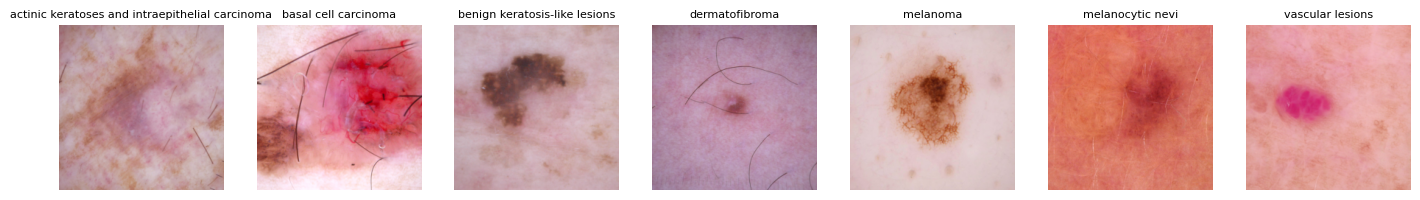

In [5]:
def show_one_per_class(dataset, class_names):
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(2*n_classes, 2))

    if n_classes == 1:
        axes = [axes]
    
    shown_classes = set()
    for img, label in dataset:
        class_idx = int(label[0])
        
        if class_idx not in shown_classes:
            ax = axes[class_idx]
            
            if hasattr(img, "numpy"): 
                img_np = img.permute(1, 2, 0).numpy()
            else:  
                img_np = np.array(img)
            
            ax.imshow(img_np)
            ax.set_title(class_names[class_idx], fontsize=8)
            ax.axis("off")
            shown_classes.add(class_idx)
        
        if len(shown_classes) == n_classes:
            break

    plt.tight_layout()
    plt.show()

show_one_per_class(train_dataset, class_names)

In [6]:
# data imbalanced, nevi dominate with small counts for other classes
# benign classes: nevi, benign keratosis, dermatofibroma, vascular lesions
# malignant classes: melanoma, basal cell carcinoma
# pre-malignant / early stage: actinic keratoses and intraepithelial carcinoma

In [7]:
img, label = train_dataset[0]
print(np.array(img).shape)
info["n_channels"]

(224, 224, 3)


3

In [8]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [9]:
train_dataset = DermaMNIST(
    split="train",
    transform=train_transform,   
    download=True,
    size=224
)

val_dataset = DermaMNIST(
    split="val",
    transform=test_transform,
    download=True,
    size=224
)

test_dataset = DermaMNIST(
    split="test",
    transform=test_transform,
    download=True,
    size=224
)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

n_classes = len(train_dataset.info["label"])

In [11]:
def get_efficientnet_b0():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model.to(device)

def get_efficientnet_b1():
    model = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, n_classes)
    return model.to(device)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

def compute_auc(model, loader, split):
    model.eval()
    
    y_true = []
    y_score = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

            y_true.append(labels.cpu())
            y_score.append(probs.cpu())

    y_true = torch.cat(y_true).numpy()
    y_score = torch.cat(y_score).numpy()

    evaluator = Evaluator("dermamnist", split)
    metrics = evaluator.evaluate(y_score)

    return metrics

In [12]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [13]:
effnet_b0 = get_efficientnet_b0()
effnet_b0 = train_model(effnet_b0, train_loader, val_loader, epochs=10)

test_acc_b0 = evaluate(effnet_b0, test_loader)

print(f"EfficientNet-b0 Test Accuracy: {test_acc_b0:.4f}")

val_auc_b0 = compute_auc(effnet_b0, val_loader, split="val")
test_auc_b0 = compute_auc(effnet_b0, test_loader, split="test")

print("EfficientNet-b0 Val Metrics:", val_auc_b0)
print("EfficientNet-b0 Test Metrics:", test_auc_b0)

Epoch 1/10 | Loss: 76.1733 | Val Acc: 0.8116
Epoch 2/10 | Loss: 52.9098 | Val Acc: 0.8275
Epoch 3/10 | Loss: 44.6462 | Val Acc: 0.8475
Epoch 4/10 | Loss: 39.4420 | Val Acc: 0.8375
Epoch 5/10 | Loss: 36.4689 | Val Acc: 0.8694
Epoch 6/10 | Loss: 30.4779 | Val Acc: 0.8554
Epoch 7/10 | Loss: 29.1298 | Val Acc: 0.8554
Epoch 8/10 | Loss: 25.0028 | Val Acc: 0.8564
Epoch 9/10 | Loss: 22.1877 | Val Acc: 0.8504
Epoch 10/10 | Loss: 21.9857 | Val Acc: 0.8634
EfficientNet-b0 Test Accuracy: 0.8613
EfficientNet-b0 Val Metrics: Metrics(AUC=0.9728543419338891, ACC=0.8634097706879362)
EfficientNet-b0 Test Metrics: Metrics(AUC=0.9783541088660446, ACC=0.8613466334164589)


In [14]:
effnet_b1 = get_efficientnet_b1()
effnet_b1 = train_model(effnet_b1, train_loader, val_loader, epochs=10)

test_acc_b1 = evaluate(effnet_b1, test_loader)

print(f"EfficientNet-b1 Test Accuracy: {test_acc_b1:.4f}")

val_auc_b1 = compute_auc(effnet_b1, val_loader, split="val")
test_auc_b1 = compute_auc(effnet_b1, test_loader, split="test")

print("EfficientNet-b1 Val Metrics:", val_auc_b1)
print("EfficientNet-b1 Test Metrics:", test_auc_b1)

Epoch 1/10 | Loss: 75.9963 | Val Acc: 0.8235
Epoch 2/10 | Loss: 51.5271 | Val Acc: 0.8415
Epoch 3/10 | Loss: 42.5268 | Val Acc: 0.8594
Epoch 4/10 | Loss: 35.3578 | Val Acc: 0.8684
Epoch 5/10 | Loss: 28.8815 | Val Acc: 0.8554
Epoch 6/10 | Loss: 26.2014 | Val Acc: 0.8754
Epoch 7/10 | Loss: 22.6472 | Val Acc: 0.8734
Epoch 8/10 | Loss: 19.9737 | Val Acc: 0.8714
Epoch 9/10 | Loss: 17.8665 | Val Acc: 0.8554
Epoch 10/10 | Loss: 15.4019 | Val Acc: 0.8774
EfficientNet-b1 Test Accuracy: 0.8768
EfficientNet-b1 Val Metrics: Metrics(AUC=0.9801711507323718, ACC=0.8773678963110668)
EfficientNet-b1 Test Metrics: Metrics(AUC=0.9837660991939398, ACC=0.8768079800498753)


In [15]:
# https://github.com/Peachypie98/CBAM
import torch.nn.functional as F

class CAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()

        self.linear = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(inplace=True),
            nn.Linear(channels // r, channels)
        )

    def forward(self, x):
        max_pool = F.adaptive_max_pool2d(x, 1)
        avg_pool = F.adaptive_avg_pool2d(x, 1)

        b, c, _, _ = x.size()

        max_out = self.linear(max_pool.view(b, c)).view(b, c, 1, 1)
        avg_out = self.linear(avg_pool.view(b, c)).view(b, c, 1, 1)

        attention = torch.sigmoid(max_out + avg_out)
        return attention * x


class SAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)

        concat = torch.cat([max_pool, avg_pool], dim=1)
        attention = torch.sigmoid(self.conv(concat))

        return attention * x


class CBAM(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()
        self.cam = CAM(channels, r)
        self.sam = SAM()

    def forward(self, x):
        out = self.cam(x)
        out = self.sam(out)
        return out + x

In [16]:
class EfficientNet_CBAM(nn.Module):
    def __init__(self, model_name, n_classes):
        super().__init__()

        if model_name == "efficientnet_b0":
            self.backbone = models.efficientnet_b0(pretrained=True)
        elif model_name == "efficientnet_b1":
            self.backbone = models.efficientnet_b1(pretrained=True)

        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.attention = CBAM(num_features)
        self.classifier = nn.Linear(num_features, n_classes)

    def forward(self, x):
        x = self.backbone.features(x)

        x = self.attention(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [17]:
efficientnet_b0_cbam = EfficientNet_CBAM("efficientnet_b0", n_classes).to(device)
efficientnet_b0_cbam = train_model(efficientnet_b0_cbam, train_loader, val_loader, epochs=5)

test_acc_b0_cbam = evaluate(efficientnet_b0_cbam, test_loader)
print(f"EfficientNet-B0 Test Accuracy: {test_acc_b0_cbam:.4f}")

val_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, val_loader, split="val")
test_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, test_loader, split="test")

print("EfficientNet-B0 Val Metrics:", val_auc_b0_cbam)
print("EfficientNet-B0 Test Metrics:", test_auc_b0_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 77.6112 | Val Acc: 0.8026
Epoch 2/5 | Loss: 54.2941 | Val Acc: 0.8076
Epoch 3/5 | Loss: 45.6764 | Val Acc: 0.8136
Epoch 4/5 | Loss: 39.6641 | Val Acc: 0.8445
Epoch 5/5 | Loss: 35.7025 | Val Acc: 0.8584
EfficientNet-B0 Test Accuracy: 0.8524
EfficientNet-B0 Val Metrics: Metrics(AUC=0.9690137091495448, ACC=0.8584247258225324)
EfficientNet-B0 Test Metrics: Metrics(AUC=0.9703219284588437, ACC=0.8523690773067332)


In [18]:
efficientnet_b0_cbam = EfficientNet_CBAM("efficientnet_b0", n_classes).to(device)
efficientnet_b0_cbam = train_model(efficientnet_b0_cbam, train_loader, val_loader, epochs=5, lr=1e-4)

test_acc_b0_cbam = evaluate(efficientnet_b0_cbam, test_loader)
print(f"EfficientNet-B0 Test Accuracy: {test_acc_b0_cbam:.4f}")

val_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, val_loader, split="val")
test_auc_b0_cbam = compute_auc(efficientnet_b0_cbam, test_loader, split="test")

print("EfficientNet-B0 Val Metrics:", val_auc_b0_cbam)
print("EfficientNet-B0 Test Metrics:", test_auc_b0_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 78.3046 | Val Acc: 0.8146
Epoch 2/5 | Loss: 53.1873 | Val Acc: 0.8405
Epoch 3/5 | Loss: 47.2785 | Val Acc: 0.8355
Epoch 4/5 | Loss: 39.4222 | Val Acc: 0.8355
Epoch 5/5 | Loss: 37.4171 | Val Acc: 0.8774
EfficientNet-B0 Test Accuracy: 0.8718
EfficientNet-B0 Val Metrics: Metrics(AUC=0.9761327811638566, ACC=0.8773678963110668)
EfficientNet-B0 Test Metrics: Metrics(AUC=0.9749644955883683, ACC=0.8718204488778055)


In [19]:
efficientnet_b1_cbam = EfficientNet_CBAM("efficientnet_b1", n_classes).to(device)
efficientnet_b1_cbam = train_model(efficientnet_b1_cbam, train_loader, val_loader, epochs=5)

test_acc_b1_cbam = evaluate(efficientnet_b1_cbam, test_loader)
print(f"EfficientNet-B1 Test Accuracy: {test_acc_b1_cbam:.4f}")

val_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, val_loader, split="val")
test_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, test_loader, split="test")

print("EfficientNet-B1 Val Metrics:", val_auc_b1_cbam)
print("EfficientNet-B1 Test Metrics:", test_auc_b1_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 72.1656 | Val Acc: 0.8086
Epoch 2/5 | Loss: 49.8591 | Val Acc: 0.8495
Epoch 3/5 | Loss: 42.2263 | Val Acc: 0.8385
Epoch 4/5 | Loss: 35.8512 | Val Acc: 0.8544
Epoch 5/5 | Loss: 29.9679 | Val Acc: 0.8495
EfficientNet-B1 Test Accuracy: 0.8474
EfficientNet-B1 Val Metrics: Metrics(AUC=0.9725592615311853, ACC=0.8494516450648056)
EfficientNet-B1 Test Metrics: Metrics(AUC=0.9755504832347314, ACC=0.8473815461346633)


In [20]:
efficientnet_b1_cbam = EfficientNet_CBAM("efficientnet_b1", n_classes).to(device)
efficientnet_b1_cbam = train_model(efficientnet_b1_cbam, train_loader, val_loader, epochs=5, lr=1e-4)

test_acc_b1_cbam = evaluate(efficientnet_b1_cbam, test_loader)
print(f"EfficientNet-B1 Test Accuracy: {test_acc_b1_cbam:.4f}")

val_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, val_loader, split="val")
test_auc_b1_cbam = compute_auc(efficientnet_b1_cbam, test_loader, split="test")

print("EfficientNet-B1 Val Metrics:", val_auc_b1_cbam)
print("EfficientNet-B1 Test Metrics:", test_auc_b1_cbam)

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Loss: 74.1912 | Val Acc: 0.7896
Epoch 2/5 | Loss: 51.8451 | Val Acc: 0.8195
Epoch 3/5 | Loss: 42.3881 | Val Acc: 0.8265
Epoch 4/5 | Loss: 36.0996 | Val Acc: 0.8455
Epoch 5/5 | Loss: 31.9542 | Val Acc: 0.8445
EfficientNet-B1 Test Accuracy: 0.8613
EfficientNet-B1 Val Metrics: Metrics(AUC=0.9719588949104863, ACC=0.8444666001994018)
EfficientNet-B1 Test Metrics: Metrics(AUC=0.9798840633842076, ACC=0.8613466334164589)


In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib as mpl

def run_gradcam_grid(model, dataset, indices):
    model.eval()
    target_layer = model.backbone.features[-1]
    cam = GradCAM(model=model, target_layers=[target_layer])

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        input_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred)]
        )[0]

        rgb_img = img.permute(1, 2, 0).cpu().numpy()
        rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        ax.imshow(visualization)
        ax.set_title(f"Idx {idx}\nT:{label} P:{pred}")
        ax.axis("off")

    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])

    norm = mpl.colors.Normalize(vmin=0, vmax=1)
    sm = mpl.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Attention intensity (Grad-CAM)", rotation=90, labelpad=12)

    plt.show()

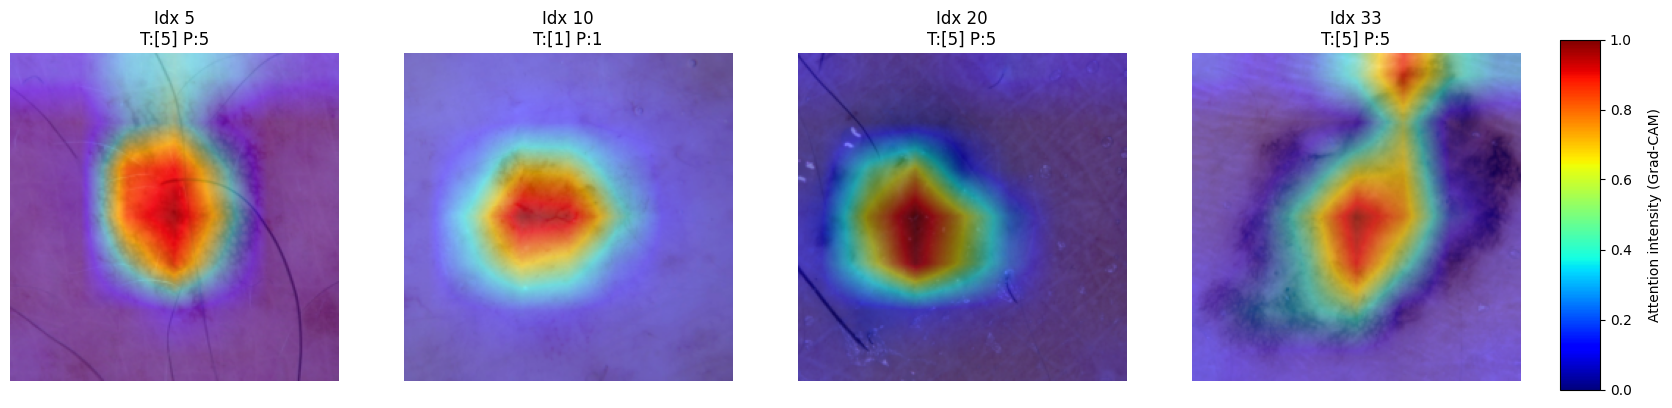

In [22]:
run_gradcam_grid(efficientnet_b0_cbam, test_dataset, [5, 10, 20, 33])

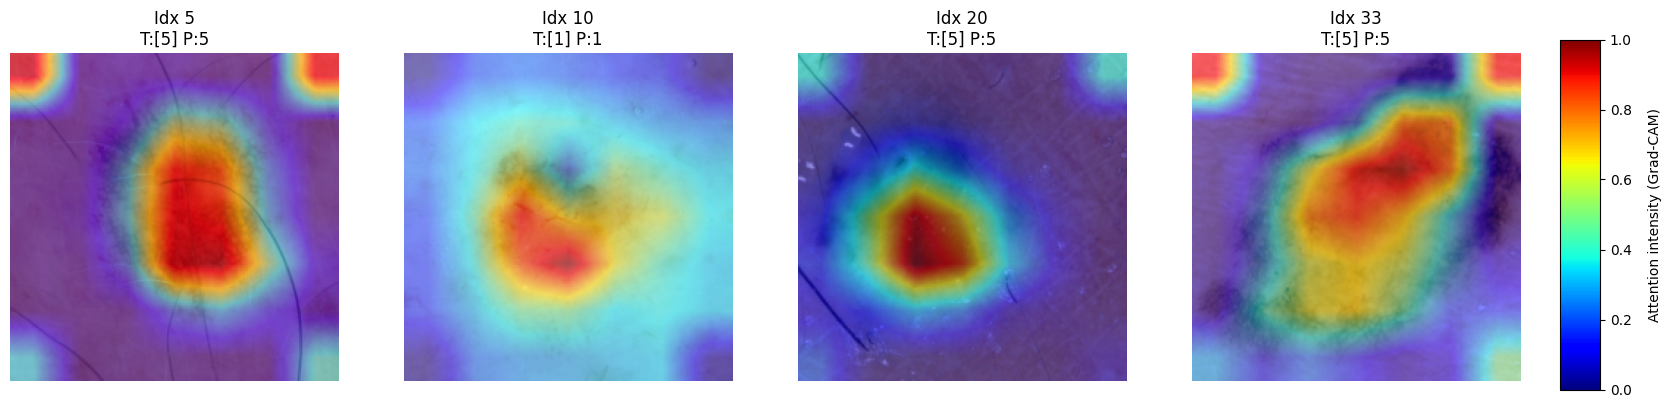

In [23]:
run_gradcam_grid(efficientnet_b1_cbam, test_dataset, [5, 10, 20, 33])

In [24]:
from medimeta import MedIMeta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

import os
from collections import Counter, defaultdict

W0505 03:16:55.670000 83366 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [25]:
ext_dataset = MedIMeta("/Users/diana/Desktop/Life in Boston/Course/BMI 712/Group_project", "skinl_derm", "Diagnosis")
sample = ext_dataset[0]

print("Sample image shape:", sample[0].shape)
print("Sample label:", sample[1])
print("Dataset size:", len(ext_dataset))

Sample image shape: torch.Size([3, 224, 224])
Sample label: tensor(0)
Dataset size: 1011


In [26]:
ann = pd.read_csv("/Users/diana/Desktop/Life in Boston/Course/BMI 712/Group_project/skinl_derm/annotations.csv")
df = ann[["filepath","split","Diagnosis","Diagnosis grouped","diagnosis"]].copy()
df.head()

,filepath,split,Diagnosis,Diagnosis grouped,diagnosis
0,images/000000.tiff,train,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
1,images/000001.tiff,val,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
2,images/000002.tiff,train,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
3,images/000003.tiff,test,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma
4,images/000004.tiff,train,basal cell carcinoma,basal cell carcinoma,basal cell carcinoma


In [27]:
summary_df = (df.groupby(["Diagnosis", "split"]).size().reset_index(name="count"))
summary_wide = summary_df.pivot(index="Diagnosis", columns="split", values="count").fillna(0)
summary_wide["total"] = summary_wide.sum(axis=1)
summary_wide = summary_wide.reset_index()
summary_wide["proportion"] = summary_wide["total"] / summary_wide["total"].sum()
summary_wide

split,Diagnosis,test,train,val,total,proportion
0,basal cell carcinoma,16,19,7,42,0.041543
1,blue nevus,11,14,3,28,0.027695
2,clark nevus,156,176,67,399,0.394659
3,combined nevus,5,5,3,13,0.012859
4,congenital nevus,4,11,2,17,0.016815
5,dermal nevus,8,19,6,33,0.032641
6,dermatofibroma,7,6,7,20,0.019782
7,lentigo,12,7,5,24,0.023739
8,melanoma,101,90,61,252,0.249258
9,melanosis,6,7,3,16,0.015826


In [28]:
collapse_map = {
    "basal cell carcinoma": "basal cell carcinoma",
    "blue nevus": "melanocytic nevi",
    "clark nevus": "melanocytic nevi",
    "combined nevus": "melanocytic nevi",
    "congenital nevus": "melanocytic nevi",
    "dermal nevus": "melanocytic nevi",
    "recurrent nevus": "melanocytic nevi",
    "reed or spitz nevus": "melanocytic nevi",
    "dermatofibroma": "dermatofibroma",
    "lentigo": "benign keratosis-like lesions",
    "seborrheic keratosis": "benign keratosis-like lesions",
    "melanoma": "melanoma",
    "vascular lesion": "vascular lesions",

    "melanosis": np.nan,
    "miscellaneous": np.nan
}
df["class"] = df["Diagnosis"].map(collapse_map)
df_external = df.dropna(subset=["class"]).copy()

In [29]:
sum_df_new = (df_external.groupby(["class", "split"]).size().reset_index(name="count"))
sum_df_new = sum_df_new.pivot(index="class", columns="split", values="count").fillna(0)
sum_df_new["total"] = sum_df_new.sum(axis=1)
sum_df_new = sum_df_new.reset_index()
sum_df_new["proportion"] = sum_df_new["total"] / sum_df_new["total"].sum()
sum_df_new

split,class,test,train,val,total,proportion
0,basal cell carcinoma,16,19,7,42,0.042553
1,benign keratosis-like lesions,31,23,15,69,0.069909
2,dermatofibroma,7,6,7,20,0.020263
3,melanocytic nevi,219,256,100,575,0.582573
4,melanoma,101,90,61,252,0.255319
5,vascular lesions,13,9,7,29,0.029382


In [30]:
shared_classes = [
    "basal cell carcinoma",
    "benign keratosis-like lesions",
    "dermatofibroma",
    "melanoma",
    "melanocytic nevi",
    "vascular lesions"
]
class_to_id = {c: i for i, c in enumerate(shared_classes)}
df_external["class_id"] = df_external["class"].map(class_to_id)
print(class_to_id)

{'basal cell carcinoma': 0, 'benign keratosis-like lesions': 1, 'dermatofibroma': 2, 'melanoma': 3, 'melanocytic nevi': 4, 'vascular lesions': 5}


In [31]:
info = INFO["dermamnist"]
medmnist_labels = {
    k: int(v) for v, k in info["label"].items()
}

print(medmnist_labels)

{'actinic keratoses and intraepithelial carcinoma': 0, 'basal cell carcinoma': 1, 'benign keratosis-like lesions': 2, 'dermatofibroma': 3, 'melanoma': 4, 'melanocytic nevi': 5, 'vascular lesions': 6}


In [32]:
medmnist_to_medimeta = {}
for label, medmnist_id in medmnist_labels.items():
    if label in class_to_id:
        medmnist_to_medimeta[medmnist_id] = class_to_id[label]

print(medmnist_to_medimeta)

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}


In [33]:
X_list = []
y_list = []

for idx in df_external.index:
    x, _ = ext_dataset[idx]

    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    else:
        x = np.array(x)

    X_list.append(x)
    y_list.append(df_external.loc[idx, "class_id"])

X_ext = np.stack(X_list)
y_ext = np.array(y_list)

print("Full filtered X shape:", X_ext.shape)
print("Full filtered y shape:", y_ext.shape)

Full filtered X shape: (987, 3, 224, 224)
Full filtered y shape: (987,)


In [34]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class ExternalSkinDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        label = self.y[idx]

        if img.shape[0] == 3:
            img = np.transpose(img, (1, 2, 0))

        img = Image.fromarray(img.astype(np.uint8))

        if self.transform:
            img = self.transform(img)

        return img, label

external_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

external_dataset = ExternalSkinDataset(
    X_ext,
    y_ext,
    transform=external_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False
)

In [35]:
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def evaluate_external_full(model, loader, class_names):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)         
            outputs = outputs[:, 1:]         

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    print(f"\nExternal Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    ))

   
    n_classes = len(class_names)
    y_true_bin = label_binarize(
        all_labels,
        classes=list(range(n_classes))
    )
    macro_auc = roc_auc_score(
        y_true_bin,
        all_probs,
        average="macro",
        multi_class="ovr"
    )
    print(f"\nExternal AUC: {macro_auc:.4f}")

    return {
        "accuracy": acc,
        "macro_auc": macro_auc,
        "y_true": all_labels,
        "y_pred": all_preds
    }

In [36]:
results = evaluate_external_full(
    model=effnet_b0,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.5826

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.58      1.00      0.74       575
             vascular lesions       0.00      0.00      0.00        29

                     accuracy                           0.58       987
                    macro avg       0.10      0.17      0.12       987
                 weighted avg       0.34      0.58      0.43       987


External AUC: 0.5138


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [37]:
results = evaluate_external_full(
    model=efficientnet_b0_cbam,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.5826

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.58      1.00      0.74       575
             vascular lesions       0.00      0.00      0.00        29

                     accuracy                           0.58       987
                    macro avg       0.10      0.17      0.12       987
                 weighted avg       0.34      0.58      0.43       987


External AUC: 0.5345


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [38]:
results = evaluate_external_full(
    model=effnet_b1,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.5826

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.58      1.00      0.74       575
             vascular lesions       0.00      0.00      0.00        29

                     accuracy                           0.58       987
                    macro avg       0.10      0.17      0.12       987
                 weighted avg       0.34      0.58      0.43       987


External AUC: 0.5077


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [39]:
results = evaluate_external_full(
    model=efficientnet_b1_cbam,          
    loader=external_loader,
    class_names=shared_classes
)


External Accuracy: 0.5593

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.00      0.00      0.00       252
             melanocytic nevi       0.58      0.96      0.72       575
             vascular lesions       0.00      0.00      0.00        29

                     accuracy                           0.56       987
                    macro avg       0.10      0.16      0.12       987
                 weighted avg       0.34      0.56      0.42       987


External AUC: 0.4792


/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

Available splits: {'train': 403, 'test': 387, 'val': 197}

Extracting features from frozen backbone...
  train split x5 augmented passes...


  aug passes:   0%|          | 0/5 [00:00<?, ?it/s]

  extracting:   0%|          | 0/7 [00:00<?, ?it/s]

  extracting:   0%|          | 0/7 [00:00<?, ?it/s]

  extracting:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 13/15 | Loss: 32.5836 | Val Acc: 0.5076 | LR: 2.50e-04


  Epoch 14/15:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 14/15 | Loss: 32.6374 | Val Acc: 0.5178 | LR: 2.50e-04 <- best


  Epoch 15/15:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 15/15 | Loss: 32.6597 | Val Acc: 0.5127 | LR: 2.50e-04

Restoring best weights (val acc = 0.5178)


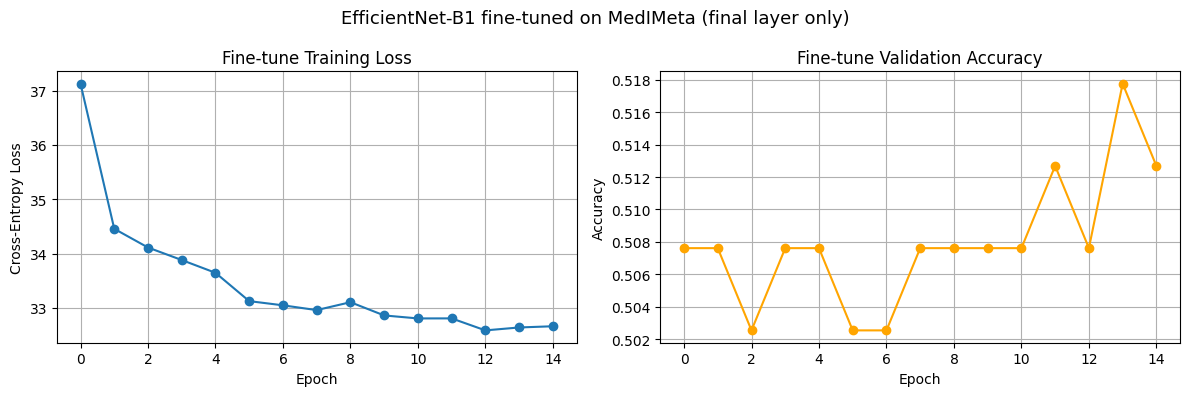


  EfficientNet-B1 fine-tuned — Val
  Accuracy : 0.5178

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00         7
benign keratosis-like lesions       0.00      0.00      0.00        15
               dermatofibroma       0.00      0.00      0.00         7
                     melanoma       0.53      0.15      0.23        61
             melanocytic nevi       0.52      0.93      0.66       100
             vascular lesions       0.00      0.00      0.00         7

                     accuracy                           0.52       197
                    macro avg       0.17      0.18      0.15       197
                 weighted avg       0.43      0.52      0.41       197

  Macro AUC : 0.5370

  EfficientNet-B1 fine-tuned — Test
  Accuracy : 0.5530

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma    

/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/bmi712/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

  extracting:   0%|          | 0/16 [00:00<?, ?it/s]


  EfficientNet-B1 fine-tuned — Full External
  Accuracy : 0.5724

Classification Report:
                               precision    recall  f1-score   support

         basal cell carcinoma       0.00      0.00      0.00        42
benign keratosis-like lesions       0.00      0.00      0.00        69
               dermatofibroma       0.00      0.00      0.00        20
                     melanoma       0.35      0.13      0.19       252
             melanocytic nevi       0.59      0.93      0.72       575
             vascular lesions       0.00      0.00      0.00        29

                     accuracy                           0.57       987
                    macro avg       0.16      0.18      0.15       987
                 weighted avg       0.44      0.57      0.47       987

  Macro AUC : 0.5959

--- Summary ---
  Before -> Accuracy: 0.5826 | AUC: 0.5077
  After  -> Accuracy: 0.5724 | AUC: 0.5959


In [42]:
import copy
from sklearn.model_selection import train_test_split

# =============================================================================
# TRANSFER LEARNING: Fine-tune effnet_b1 final layer on MedIMeta
#
# Speed strategy: pre-compute and cache backbone features ONCE.
# Training then only runs the tiny linear head, not the full backbone.
# =============================================================================

# -----------------------------------------------------------------------------
# 1.  Build split masks
# -----------------------------------------------------------------------------
df_external_reset = df_external.reset_index(drop=True)
print("Available splits:", df_external_reset["split"].value_counts().to_dict())

train_mask = df_external_reset["split"] == "train"
val_mask   = df_external_reset["split"] == "val"
test_mask  = df_external_reset["split"] == "test"

# If MedIMeta has no val split, carve 15% of train as val
if val_mask.sum() == 0:
    train_idx_arr = np.where(train_mask.values)[0]
    tr_idx, va_idx = train_test_split(
        train_idx_arr, test_size=0.15, random_state=42,
        stratify=y_ext[train_idx_arr]
    )
    train_mask_vals = np.zeros(len(df_external_reset), dtype=bool)
    val_mask_vals   = np.zeros(len(df_external_reset), dtype=bool)
    train_mask_vals[tr_idx] = True
    val_mask_vals[va_idx]   = True
    print("Created val split from train (15%).")
else:
    train_mask_vals = train_mask.values
    val_mask_vals   = val_mask.values

test_mask_vals = test_mask.values


# -----------------------------------------------------------------------------
# 2.  Extract backbone features ONCE (no gradient, no repeated forward passes)
# -----------------------------------------------------------------------------
ft_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3),
])

def extract_features(backbone, X, y, transform, batch_size=64):
    """
    Run X through the frozen backbone once and return (features, labels) tensors.
    backbone should output feature vectors, not class logits.
    """
    dataset = ExternalSkinDataset(X, y, transform=transform)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    backbone.eval()
    all_feats, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            # Run up to avgpool to get feature vectors
            x = backbone.features(images)
            x = backbone.avgpool(x)
            x = torch.flatten(x, 1)
            all_feats.append(x.cpu())
            all_labels.append(labels)

    return torch.cat(all_feats), torch.cat(all_labels)


from tqdm.auto import tqdm

def extract_features(backbone, X, y, transform, batch_size=64):
    dataset = ExternalSkinDataset(X, y, transform=transform)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    backbone.eval()
    all_feats, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False, desc="  extracting"):
            images = images.to(device)
            x = backbone.features(images)
            x = backbone.avgpool(x)
            x = torch.flatten(x, 1)
            all_feats.append(x.cpu())
            all_labels.append(labels)

    return torch.cat(all_feats), torch.cat(all_labels)

ft_train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3),
])

# For train: extract N_AUG differently-augmented copies of the dataset and
# concatenate them. This gives the head the same variety it would get from
# running the backbone every epoch, but the backbone still only runs N_AUG
# times total instead of once per epoch for all 15 epochs.
N_AUG = 5   # equivalent to 5 epochs worth of augmented views; adjust as needed

print("\nExtracting features from frozen backbone...")
print(f"  train split x{N_AUG} augmented passes...", flush=True)
train_feat_list, train_label_list = [], []
for i in tqdm(range(N_AUG), desc="  aug passes"):
    feats, labels = extract_features(effnet_b1, X_ext[train_mask_vals], y_ext[train_mask_vals], ft_train_transform)
    train_feat_list.append(feats)
    train_label_list.append(labels)
train_feats  = torch.cat(train_feat_list)
train_labels = torch.cat(train_label_list)

print("  val split...", flush=True)
val_feats,   val_labels   = extract_features(effnet_b1, X_ext[val_mask_vals],   y_ext[val_mask_vals],   ft_eval_transform)
print("  test split...", flush=True)
test_feats,  test_labels  = extract_features(effnet_b1, X_ext[test_mask_vals],  y_ext[test_mask_vals],  ft_eval_transform)
print(f"Done — train: {train_feats.shape}, val: {val_feats.shape}, test: {test_feats.shape}")


# -----------------------------------------------------------------------------
# 3.  Lightweight TensorDataset loaders for feature vectors
# -----------------------------------------------------------------------------
from torch.utils.data import TensorDataset

feat_train_loader = DataLoader(TensorDataset(train_feats, train_labels), batch_size=64, shuffle=True)
feat_val_loader   = DataLoader(TensorDataset(val_feats,   val_labels),   batch_size=64, shuffle=False)
feat_test_loader  = DataLoader(TensorDataset(test_feats,  test_labels),  batch_size=64, shuffle=False)


# -----------------------------------------------------------------------------
# 4.  Build the fine-tune model: frozen backbone + fresh 6-class head
# -----------------------------------------------------------------------------
n_shared    = len(shared_classes)   # 6
in_features = effnet_b1.classifier[1].in_features

effnet_b1_ft = copy.deepcopy(effnet_b1)
for param in effnet_b1_ft.parameters():
    param.requires_grad = False

effnet_b1_ft.classifier[1] = nn.Linear(in_features, n_shared)  # unfrozen by default
effnet_b1_ft = effnet_b1_ft.to(device)

# Standalone head for fast training on cached features
head = effnet_b1_ft.classifier.to(device)   # Sequential(Dropout, Linear)

trainable_params = sum(p.numel() for p in head.parameters())
total_params     = sum(p.numel() for p in effnet_b1_ft.parameters())
print(f"\nTrainable params : {trainable_params:,}  /  Total: {total_params:,}")
print(f"  ({trainable_params / total_params * 100:.2f}% of model — classifier head only)")


# -----------------------------------------------------------------------------
# 5.  Fine-tuning loop (trains only the head on cached feature vectors)
# -----------------------------------------------------------------------------
def finetune_last_layer(head, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(head.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_val_acc = 0.0
    best_state   = None
    history      = {"train_loss": [], "val_acc": []}

    epoch_bar = tqdm(range(epochs), desc="Fine-tuning", unit="epoch")

    for epoch in epoch_bar:
        head.train()
        running_loss = 0.0

        batch_bar = tqdm(train_loader, leave=False, desc=f"  Epoch {epoch+1}/{epochs}")
        for feats, labels in batch_bar:
            feats  = feats.to(device)
            labels = labels.long().to(device)

            optimizer.zero_grad()
            loss = criterion(head(feats), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        # Validation accuracy
        head.eval()
        correct = total = 0
        with torch.no_grad():
            for feats, labels in val_loader:
                feats  = feats.to(device)
                labels = labels.long().to(device)
                correct += (head(feats).argmax(dim=1) == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total

        scheduler.step(val_acc)
        history["train_loss"].append(running_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(head.state_dict())
            marker = " <- best"
        else:
            marker = ""

        lr_now = optimizer.param_groups[0]["lr"]
        epoch_bar.set_postfix(val_acc=f"{val_acc:.4f}", loss=f"{running_loss:.4f}", lr=f"{lr_now:.2e}")
        print(f"Epoch {epoch+1:>2}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {lr_now:.2e}{marker}")

    print(f"\nRestoring best weights (val acc = {best_val_acc:.4f})")
    head.load_state_dict(best_state)
    return head, history


head, ft_history = finetune_last_layer(head, feat_train_loader, feat_val_loader, epochs=15, lr=1e-3)

# Sync the trained head weights back into the full model
effnet_b1_ft.classifier.load_state_dict(head.state_dict())


# -----------------------------------------------------------------------------
# 6.  Plot training curves
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ft_history["train_loss"], marker="o")
axes[0].set_title("Fine-tune Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True)

axes[1].plot(ft_history["val_acc"], marker="o", color="orange")
axes[1].set_title("Fine-tune Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.suptitle("EfficientNet-B1 fine-tuned on MedIMeta (final layer only)", fontsize=13)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 7.  Full evaluation on cached feature splits
#     NOTE: no [:, 1:] offset — head outputs exactly 6 logits
# -----------------------------------------------------------------------------
def evaluate_ft_full(head, feat_loader, class_names, split_name="Test"):
    head.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for feats, labels in feat_loader:
            feats = feats.to(device)
            probs = torch.softmax(head(feats), dim=1)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n{'='*55}")
    print(f"  EfficientNet-B1 fine-tuned — {split_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    y_bin     = label_binarize(all_labels, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")
    print(f"  Macro AUC : {macro_auc:.4f}")

    return {"accuracy": acc, "macro_auc": macro_auc, "y_true": all_labels, "y_pred": all_preds}


ft_val_results  = evaluate_ft_full(head, feat_val_loader,  shared_classes, split_name="Val")
ft_test_results = evaluate_ft_full(head, feat_test_loader, shared_classes, split_name="Test")


# -----------------------------------------------------------------------------
# 8.  Before vs after comparison on full external dataset
# -----------------------------------------------------------------------------
print("\n" + "="*55)
print("  Before fine-tuning (zero-shot transfer)")
print("="*55)
pre_ft_results = evaluate_external_full(
    model=effnet_b1, loader=external_loader, class_names=shared_classes
)

print("\n" + "="*55)
print("  After fine-tuning (last layer only)")
print("="*55)
all_feats, all_labels_tensor = extract_features(effnet_b1, X_ext, y_ext, ft_eval_transform)
full_feat_loader = DataLoader(TensorDataset(all_feats, all_labels_tensor), batch_size=64, shuffle=False)

post_ft_results = evaluate_ft_full(head, full_feat_loader, shared_classes, split_name="Full External")

print("\n--- Summary ---")
print(f"  Before -> Accuracy: {pre_ft_results['accuracy']:.4f} | AUC: {pre_ft_results['macro_auc']:.4f}")
print(f"  After  -> Accuracy: {post_ft_results['accuracy']:.4f} | AUC: {post_ft_results['macro_auc']:.4f}")